# Optional Diagnostics — Supporting Analysis

This notebook is a technical appendix to `01_case_study_analysis.ipynb`.

The primary notebook answers the three ML questions and reports the final model. This appendix contains additional experiments used to investigate model behaviour, feature redundancy, group-swap assumptions, explainability, ensembles, class-0 decision rules, feature reduction and learning curves.

These experiments helped identify limitations and possible future improvements, but they did **not** change the selected model or the submitted result.

| Final submitted result |                      Value |
| ---------------------- | -------------------------: |
| Selected model         | Uncalibrated Random Forest |
| Holdout accuracy       |                     54.83% |
| Group 1 baseline       |                     46.45% |
| Estimated offline lift |    +8.38 percentage points |

Any holdout comparisons in this notebook are post-hoc diagnostics and must not be used to select a replacement model. Hypothetical cost examples are sensitivity checks, not estimates of actual ROI.

Run this notebook after `01_case_study_analysis.ipynb`. Its results are saved separately in `reports/advanced_diagnostics.json`.


In [ ]:
# ruff: noqa: E402

# This cell establishes a reproducible execution environment for the appendix.
# It imports only shared project functions, defines fixed paths/seeds, and keeps
# diagnostic outputs separate from the authoritative case-study results.
import hashlib
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split

# Resolve the repository root so the notebook works when opened either from the repository root or directly from the notebooks directory.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from notebooks.analysis_support import ( cost_sensitivity_table, decline_rule_summary, invariance_table, minimal_model_comparison, plot_feature_sweep, 
                                        plot_horizontal_importance, plot_learning_curve, position_bias_table, redundancy_report, show_pairwise_signal, 
                                        show_shap_importance, show_swap_validation, show_symmetry_diagnosis)

from src.explainability import permutation_importance_report
from src.symmetry import measure_invariance
from src.training.diagnostics import ( abstention_rule_comparison, apply_decline_rule, ensemble_experiment, feature_block_ablation, feature_count_sweep, 
                                      learning_curve_report, select_decline_threshold)

from src.training.evaluation import classification_metrics
from src.training.pipeline import build_pipeline, candidate_models, split_features_target
from src.training.splits import make_split

# Apply consistent display and plotting defaults; these settings affect only presentation, never model calculations.

pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})

# Declare all input and output locations in one place. Optional figures are sent to their own subdirectory so they cannot replace primary-report figures.
DATA_PATH = PROJECT_ROOT / "data" / "customerGroups.csv"
ARTIFACT_PATH = PROJECT_ROOT / "artifacts" / "model.pkl"
REPORTS = PROJECT_ROOT / "reports"
FIGURES = REPORTS / "figures" / "optional_diagnostics"
FIGURES.mkdir(parents=True, exist_ok=True)

# Reuse the exact seeds from the primary notebook to reconstruct its partitions.
RANDOM_STATE = 42
HOLDOUT_SEED = 20260819

# Keep appendix results isolated from the authoritative findings.json contract.
ADVANCED_RESULTS: dict = { "diagnostic_only": True, "changed_champion": False, "canonical_champion": "random_forest", 
                          "canonical_accuracy": 0.5483, "canonical_lift_pp": 8.38,}


def save_fig(fig, name: str) -> None:
    # Keep appendix figures in their own directory to protect primary-report assets.
    fig.savefig(FIGURES / name, dpi=150, bbox_inches="tight")


# Show the resolved environment before running any expensive diagnostic. 
# A missing dataset or artifact can therefore be detected immediately.
pd.DataFrame(
    {
        "value": [ str(PROJECT_ROOT), DATA_PATH.exists(), ARTIFACT_PATH.exists(), HOLDOUT_SEED ]
    },
    index=["project root", "dataset present", "artifact present", "holdout seed"],
)


,value
project root,e:\dev\campaign-group-predictor
dataset present,True
artifact present,True
holdout seed,20260819


---

## 0. Reconstruct the canonical evaluation context

The appendix loads the already-selected artifact instead of running model selection again. It reconstructs the same 64% training, 16% calibration, and 20% holdout partitions used by the primary notebook.

This is a guardrail: advanced experiments begin from the frozen champion rather than creating another route to a different “final” model.


In [ ]:
# Load the supplied campaign table. The artifact checksum below verifies that it is the same dataset used to train the submitted model.

df = pd.read_csv(DATA_PATH)

# Enforce the inference-time feature boundary: the three post-campaign columns are unavailable when a targeting decision must be made.
X, y = split_features_target(df, drop_leakage=True)

# Recreate the exact primary-notebook partitions. The holdout is used only for
# explicitly labelled post-hoc reporting in this appendix.
X_dev, X_test, y_dev, y_test = make_split( X, y, strategy="stratified", test_size=0.2, random_state=HOLDOUT_SEED, order_by=None)
X_train, X_calib, y_train, y_calib = train_test_split( X_dev, y_dev, test_size=0.2, stratify=y_dev, random_state=RANDOM_STATE)

# No symmetry augmentation is applied. Cross-validation experiments use only the 64% training partition and the same deterministic five-fold splitter.
X_fit, y_fit = X_train, y_train
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Load—not refit—the frozen production candidate and verify provenance before any diagnostic uses it.
artifact = joblib.load(ARTIFACT_PATH)
champion = artifact["pipeline"]
CHAMPION = artifact["model_name"]
NEGATE_COLUMNS = list(artifact.get("negate_columns", []))

# Recover canonical values from the artifact rather than typing a competing result into this notebook. 
# The holdout baseline is computed on the same rows.
CHAMPION_TEST_ACCURACY = float(artifact["metrics"]["accuracy"])
NAIVE_BASELINE = float((y_test == 1).mean())
dataset_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()

# Fail early if the dataset, model, leakage policy, or feature order differs from the submitted system. Diagnostics are meaningful only under the same contract.
assert CHAMPION == "random_forest", "Unexpected artifact: champion changed"
assert artifact.get("calibrated", False) is False, "Expected raw probabilities"
assert artifact.get("leakage_dropped") is True, "Artifact includes unavailable fields"
assert list(X.columns) == list(artifact["feature_columns"]), "Feature contract mismatch"
assert artifact.get("dataset_sha256") == dataset_sha256, "Dataset provenance mismatch"
assert abs(CHAMPION_TEST_ACCURACY - 0.5483) < 1e-12, "Canonical accuracy mismatch"

# Display the size and permitted role of each partition for reviewer clarity.
pd.DataFrame(
    {
        "rows": [len(X_train), len(X_calib), len(X_test)],
        "role": ["model fit and cross-validation", "diagnostic ranking and threshold selection", "post-hoc reporting only"],
    },
    index=["train", "calibration", "holdout"],
)


,rows,role
train,4236,model fit and cross-validation
calibration,1060,diagnostic ranking and threshold selection
holdout,1324,post-hoc reporting only


**Control check.** The loaded artifact is the uncalibrated Random Forest and matches the dataset SHA-256, 67-feature contract, leakage flag, and canonical 54.83% accuracy. The split is reconstructed with the documented fixed seed. Nothing in this appendix changes or reserialises the artifact.


---

## 1. Comparison-feature structure

**Question.** Do the 27 `c_` variables add independent information, and do explicit `g1_i − g2_i` differences show strong signal?

These checks describe representation and correlation. They do not select or remove features.


In [ ]:
# Check whether each comparison feature can be reconstructed from the two group  blocks. 
# This diagnoses redundant representation; it does not remove features.
# Training data only is used because this is exploratory analysis.

redundancy, n_redundant = redundancy_report(X_train)

# Persist the summary count in the appendix output and display the full table.
ADVANCED_RESULTS["n_redundant_comparison_features"] = n_redundant
redundancy


,r2,is_redundant,max_abs_corr_with_diff
feature,,,
c_10,1.0000,True,0.807
c_11,1.0000,True,0.831
c_20,1.0000,True,1.000
c_19,1.0000,True,1.000
c_18,1.0000,True,0.861
c_17,1.0000,True,0.844
c_16,1.0000,True,0.478
c_15,1.0000,True,0.652
c_14,1.0000,True,0.474


,correlation with target
diff_4,-0.1808
diff_1,0.1805
diff_12,-0.1787
diff_13,-0.1713
diff_11,-0.1688


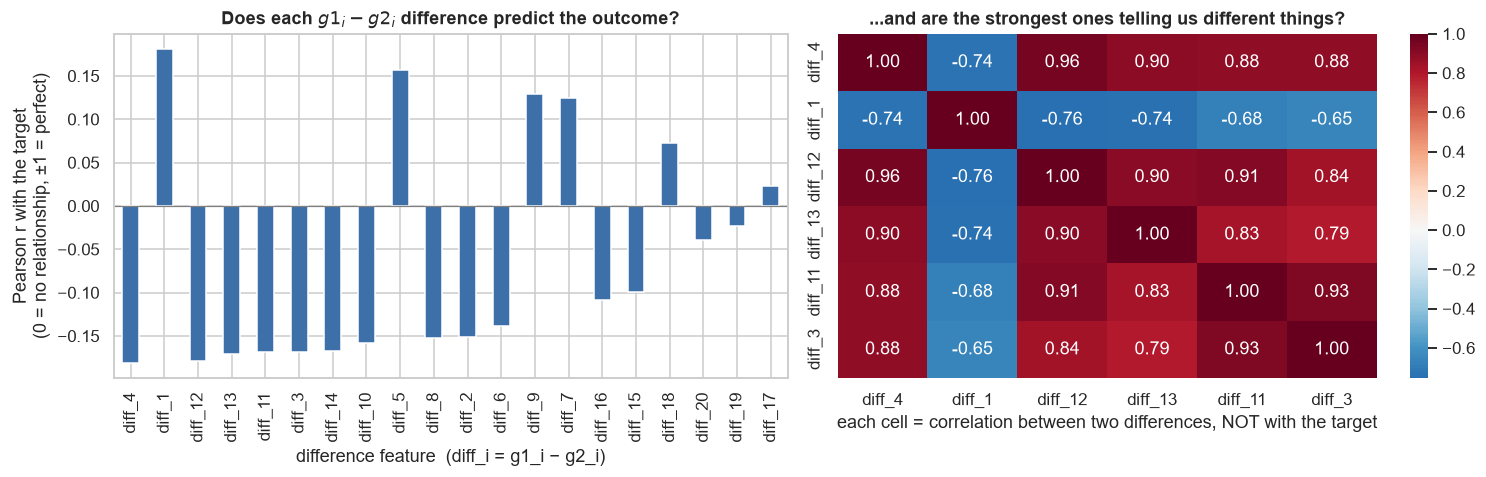

In [ ]:
# Construct paired g1_i - g2_i contrasts and measure their univariate association with the target on training rows. 
# This tests whether simple directional signal exists; it is not a feature-selection step.

pairwise = show_pairwise_signal(X_train, y_train)

# Record the strongest contrast, export its figure, and render it in the notebook.
ADVANCED_RESULTS["strongest_pairwise_difference"] = pairwise.strongest
save_fig(pairwise.figure, "01_pairwise_signal.png")
plt.show()


**Result.** Fifteen comparison variables are reconstructible from the group blocks under the diagnostic threshold. On training data, the strongest explicit difference is `diff_4` with correlation **r = −0.1808**, so no individual linear contrast is a strong predictor.

**Decision impact.** None. Correlated features can dilute importance, but Random Forest tolerates redundancy and the main pipeline keeps the full 67-feature contract. A removal decision would require CV inside a formal selection protocol.


---

## 2. Group-swap symmetry and augmentation safety

**Question.** Can each campaign be mirrored by exchanging Group 1 and Group 2, swapping labels 1↔2, and retaining class 0?

This requires two conditions:

1. Every anonymised comparison variable must have a known swap transformation.
2. Group positions must be exchangeable in the observed data.

Because the `c_` semantics are unknown, direction-dependent variables are inferred heuristically and then tested. The test is deliberately conservative: failed validation disables augmentation.


In [ ]:
# Infer which anonymised comparison columns might need sign reversal when Group 1 and Group 2 are exchanged. 
# Without a data dictionary this is only a hypothesis, not an authoritative feature transformation.
diagnosed_negate_columns = show_symmetry_diagnosis(X_train)

# Store the inferred list so the following validation is reproducible.
ADVANCED_RESULTS["diagnosed_direction_dependent_features"] = diagnosed_negate_columns


,best_match,correlation,abs_correlation,mean,skew,likely_direction_dependent
feature,,,,,,
c_21,diff_14,1.000,1.000,-0.011,-0.062,True
c_19,diff_12,1.000,1.000,-0.312,-0.106,True
c_12,diff_4,1.000,1.000,-0.173,-0.117,True
c_20,diff_13,1.000,1.000,-0.030,-0.070,True
c_22,diff_17,1.000,1.000,0.002,0.150,True
c_18,diff_12,0.861,0.861,-6.792,-0.940,False
c_17,diff_12,0.844,0.844,6.480,0.839,False
c_11,diff_4,0.831,0.831,-4.552,-0.699,False


In [ ]:
# Apply the inferred swap to training data and compare original versus swapped distributions. 
# The validation fails closed: any unresolved mismatch disables symmetry augmentation rather than manufacturing questionable training rows.

swap_verdict = show_swap_validation(X_train, diagnosed_negate_columns)
ADVANCED_RESULTS["swap_augmentation_allowed"] = swap_verdict.augment
ADVANCED_RESULTS["swap_validation_failures"] = swap_verdict.failures


Group positions are NOT exchangeable: 7 of 20 paired variables differ significantly (['var_1', 'var_15', 'var_16', 'var_18', 'var_19', 'var_20', 'var_17']). Symmetry augmentation would fabricate unrealistic rows and must not be used; the position of a group carries real information.


,ks_statistic,p_value,negated,strictly_positive,distribution_preserved
feature,,,,,
c_19,0.0255,0.1274,True,False,True
c_20,0.0241,0.1714,True,False,True
c_22,0.0234,0.1976,True,False,True
c_21,0.0170,0.5733,True,False,True
c_12,0.0083,0.9987,True,False,True
c_1,0.0000,1.0000,False,False,True
c_3,0.0000,1.0000,False,False,True
c_2,0.0000,1.0000,False,False,True


,result
columns whose distribution changed,none
negated but strictly positive,none
paired variables not exchangeable,7 of 20 differ significantly
verdict,augmentation DISABLED


In [ ]:
# Compare class-1 and class-2 frequencies on training data. 
# A position imbalance is a second reason not to assume that Group 1 and Group 2 are exchangeable, even when a column-level swap can be constructed.

bias_table, position_bias = position_bias_table(y_train)

# Store the measured position bias and display its supporting table.
ADVANCED_RESULTS["training_label_position_bias"] = position_bias
bias_table


,value
P(group 1 wins),46.46%
P(group 2 wins),28.35%
position bias in the labels,+18.11%


**Result.** The heuristic identifies five likely signed comparison variables. The inferred mirror preserves their marginal training distributions, but seven of 20 paired Group-1/Group-2 variables differ significantly. Group 1 wins **18.11 percentage points** more often than Group 2.

**Decision impact.** Symmetry augmentation remains **disabled**. Mirroring would impose an assumption the data does not support and could manufacture unrealistic rows. The result does not prove why positions differ; it only shows that exchangeability cannot be assumed.


---

## 3. Explainability cross-check

**Question.** Do two different importance methods identify the same dominant predictors?

Permutation importance is already reported in the primary notebook. It is recomputed here on the same calibration partition only because the complete ranking is required by the SHAP comparison, feature-count sweep and minimal-model diagnostics. It does not create a second feature-selection decision. SHAP is an optional, slower corroboration and requires the optional dependency set.


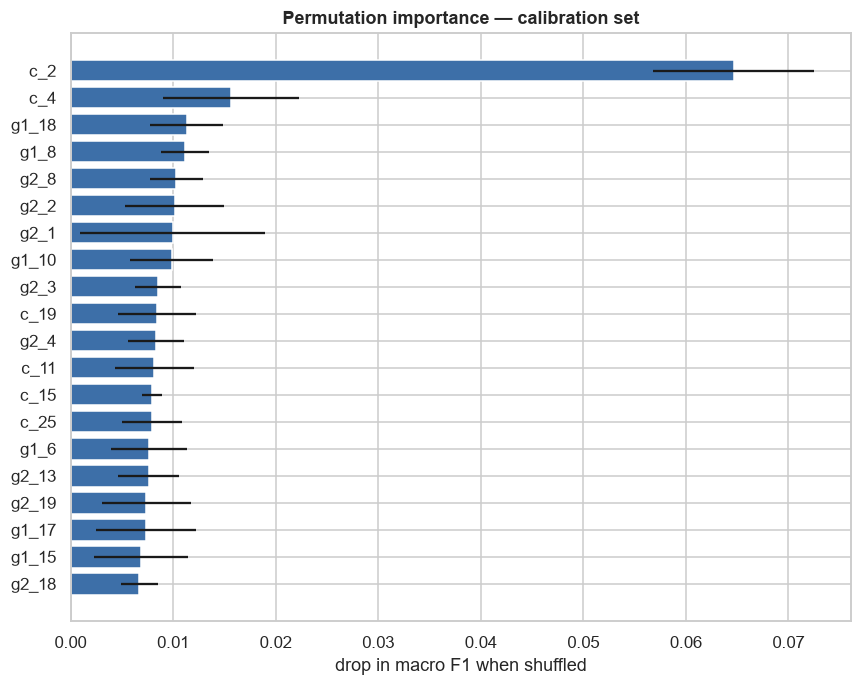

,importance_mean,importance_std,rank
feature,,,
c_2,0.06466,0.00785,1
c_4,0.01568,0.00664,2
g1_18,0.01132,0.00359,3
g1_8,0.01116,0.00233,4
g2_8,0.01030,0.00259,5
g2_2,0.01017,0.00482,6
g2_1,0.00995,0.00906,7
g1_10,0.00986,0.00405,8
g2_3,0.00853,0.00229,9


In [ ]:
# Shuffle one feature at a time on the calibration partition and measure the resulting drop in macro F1. 
# Larger drops indicate greater predictive reliance. 
# The reused holdout is deliberately excluded from ranking.

perm = permutation_importance_report( champion, X_calib, y_calib, n_repeats=10, random_state=RANDOM_STATE)

# Store the top-ten names for traceability. 
# This ranking supports downstream diagnostics but does not change the deployed 67-feature contract.
ADVANCED_RESULTS["permutation_top_10"] = perm.head(10).index.tolist()

# Plot the 20 leading features with repeat-to-repeat uncertainty bars.
fig = plot_horizontal_importance( perm, "importance_mean", "Permutation importance — calibration set", 
                                 "drop in macro F1 when shuffled", error_column="importance_std")

save_fig(fig, "02_permutation_importance.png")
plt.show()

# Display the exact top-ten importance means and standard deviations.
perm.head(10).style.format({"importance_mean": "{:.5f}", "importance_std": "{:.5f}"})


Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.
100%|===================| 899/900 [06:18<00:00]        

,mean_abs_shap,rank
feature,,
c_2,0.04589,1
diff_1,0.01204,2
c_4,0.01185,3
ratio_1,0.01138,4
g1_1,0.01005,5
g2_1,0.00964,6
c_26,0.00530,7
c_25,0.00448,8
c_19,0.00360,9


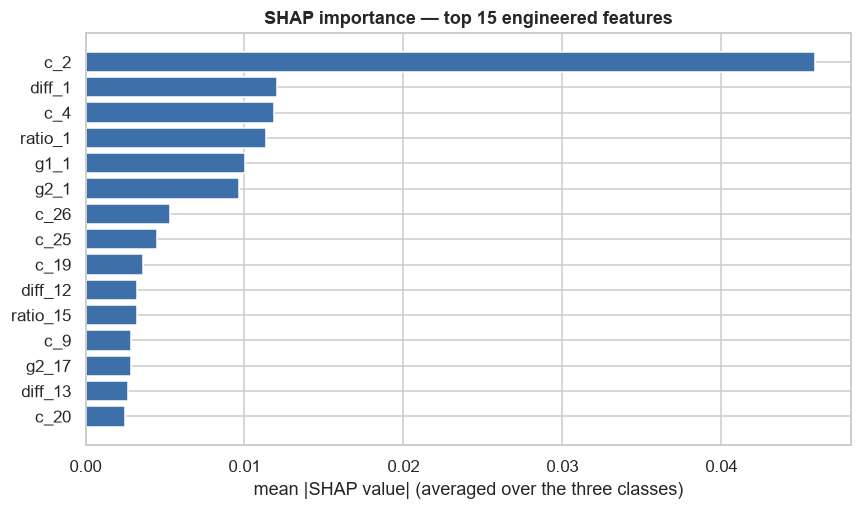

In [9]:
# Cross-check the permutation ranking with SHAP on at most 300 calibration rows to control runtime. 
# SHAP describes model dependence, not causal business impact.
fig = show_shap_importance(champion, X_calib, max_samples=300, top_n=15)

# The helper returns None when the optional SHAP dependency is unavailable; the rest of the appendix remains executable in that case.
if fig is not None:
    save_fig(fig, "03_shap_importance.png")
    plt.show()


**Result.** `c_2` ranks first under both permutation importance and SHAP. `c_4` and variables derived from the first group-pair contrast also appear near the top.

**Decision impact.** This agreement supports `c_2` as a predictive diagnostic, not a causal explanation. The feature is anonymised, so the correct follow-up is to recover its business definition and lineage. The deployed feature set is unchanged.


---

## 4. Ensemble experiment

**Question.** Does combining model families improve CV accuracy enough to justify the additional serving and maintenance complexity?

This experiment uses reduced model configurations and three-fold CV for runtime. It is internally useful for ensemble-versus-base comparison, but its scores are not comparable with the primary seven-model leaderboard.


In [10]:
# Build a reduced candidate set for a bounded ensemble experiment. 
# Optional libraries are included only when installed, so this appendix can still run without XGBoost or CatBoost.

zoo = candidate_models(RANDOM_STATE, fast=True)
bases = {
name: build_pipeline(zoo[name])
    for name in ["random_forest", "catboost", "xgboost", "mlp"]
    if name in zoo
}

# Compare individual, voting, and stacking strategies on training data using three-fold CV. 
# This reduced protocol is exploratory and is not comparable with the primary five-fold, seven-model leaderboard.
ensemble_results = ensemble_experiment( bases, X_fit, y_fit, cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE), stacking_cv=3)

# Store and display the CV means, uncertainty, and delta from the best base model.
ADVANCED_RESULTS["ensemble_experiment"] = ( ensemble_results.reset_index().to_dict(orient="records"))
ensemble_results.style.format({"cv_mean": "{:.4f}", "cv_std": "{:.4f}", "delta_vs_best_base": "{:+.4f}"})


,cv_mean,cv_std,delta_vs_best_base,verdict
approach,,,,
stacking (logistic meta-learner),0.5963,0.0006,+0.0064,improves on best base
base: xgboost,0.5899,0.0046,+0.0000,within noise
soft voting,0.5881,0.0052,-0.0018,within noise
base: random_forest,0.5763,0.0056,-0.0136,worse than best base
base: catboost,0.5737,0.0113,-0.0162,worse than best base
base: mlp,0.5666,0.0010,-0.0233,worse than best base


**Result.** Stacking scores **0.5963**, versus **0.5899** for the best reduced base model, a **+0.0064** difference. Its three-fold standard deviation is only 0.0006, which is unusually small and should not be treated as strong evidence.

**Decision impact.** None. The experiment changes the protocol and configuration, has no independent confirmation, and would increase deployment complexity. Random Forest remains the champion.


---

## 5. Explicit decline-threshold diagnostic

**Question.** Can a separate `P(class 0)` threshold materially improve detection of unprofitable campaigns without losing more than one percentage point of accuracy?


In [11]:
# Generate probabilities on calibration data for rule selection and separately on holdout data for post-selection reporting. The forest itself is not refit.
calibration_probabilities = champion.predict_proba(X_calib)
test_probabilities = champion.predict_proba(X_test)

# Compare ordinary argmax with candidate class-0 thresholds on calibration data.
# This table reveals the recall-versus-accuracy trade-off before a rule is frozen.
display( abstention_rule_comparison( y_calib.to_numpy(), calibration_probabilities).style.format(
        {"class_0_recall": "{:.3f}", "precision_of_decline": "{:.3f}", "accuracy": "{:.4f}", }))

# Freeze the decline rule on calibration data; use holdout only to report the already-selected rule. 
# The one-percentage-point accuracy-loss limit is pre-stated.

decline_rule = select_decline_threshold( y_calib.to_numpy(), calibration_probabilities, max_accuracy_loss=0.01)
decline_predictions = apply_decline_rule( test_probabilities, decline_rule["threshold"])

# Apply the frozen rule unchanged to the holdout and compute its reporting metrics.
decline_metrics = classification_metrics(y_test.to_numpy(), decline_predictions)

# Persist both the selected rule and its holdout outcome in the appendix results.
ADVANCED_RESULTS["decline_rule"] = decline_rule
ADVANCED_RESULTS["decline_rule_holdout"] = {"accuracy": decline_metrics["accuracy"], "class_0_recall": decline_metrics["per_class"]["0"]["recall"],}

# Render a compact explanation of the retained or rejected decline policy.
decline_rule_summary( decline_rule, decline_metrics, int((decline_predictions == 0).sum()),)


,n_declined,class_0_recall,precision_of_decline,accuracy
rule,,,,
argmax,77,0.086,0.299,0.5726
decline if P(0) >= 0.20,866,0.876,0.270,0.3575
decline if P(0) >= 0.25,674,0.742,0.294,0.4368
decline if P(0) >= 0.30,394,0.461,0.312,0.5066
decline if P(0) >= 0.35,170,0.202,0.318,0.5547
decline if P(0) >= 0.40,46,0.049,0.283,0.5783
decline if P(0) >= 0.45,11,0.007,0.182,0.5811
decline if P(0) >= 0.50,0,0.000,0.000,0.5868


,value
frozen threshold,none — argmax retained
selection rule,argmax retained; no threshold beat its class-0...
test accuracy,0.5483
test class-0 recall,0.084
campaigns declined on test,109


**Result.** No candidate threshold satisfies the predefined accuracy-loss constraint while improving class-0 recall sufficiently. The selection function retains ordinary argmax.

**Decision impact.** No decline threshold is deployed. The weak class-0 recall remains an unresolved modelling limitation rather than being hidden behind a favourable threshold.


---

## 6. Feature and sample sufficiency

### 6.1 Feature-count sweep and block ablation

Features are ranked on calibration data; CV performance is then measured on training data. This separation avoids ranking on the holdout, but the sweep is still exploratory because `k` was not selected inside nested CV.


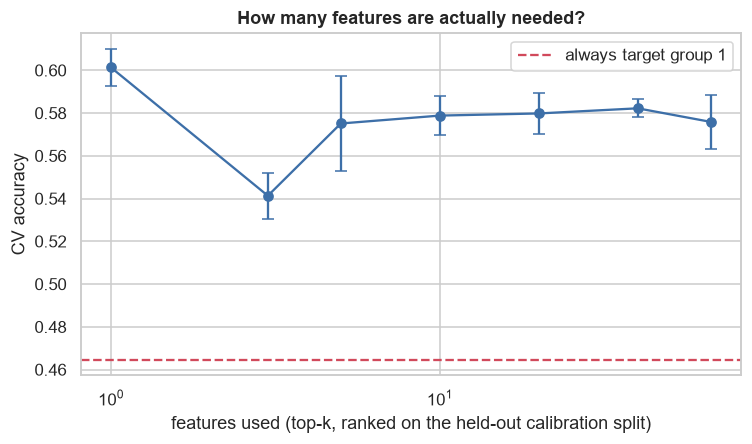

,cv_mean,cv_std,pct_of_best
n_features,,,
1,0.6013,0.0088,100.0%
3,0.5413,0.0107,90.0%
5,0.5751,0.0222,95.6%
10,0.5788,0.0091,96.3%
20,0.5798,0.0097,96.4%
40,0.5822,0.0042,96.8%
67,0.5758,0.0124,95.8%


In [12]:
# Take the feature order from calibration-only permutation importance, then test increasing feature counts with CV on training rows. 
# Because k is not selected inside nested CV, this experiment can generate hypotheses but cannot replace the submitted model.

feature_sweep = feature_count_sweep( lambda: build_pipeline(candidate_models(RANDOM_STATE)[CHAMPION]), X_fit, y_fit, 
                                    ranked_features=perm.index.tolist(), cv=cv, counts=(1, 3, 5, 10, 20, 40, 67))

# Store the exact curve, then visualise accuracy versus feature count and baseline.

ADVANCED_RESULTS["feature_count_sweep"] = ( feature_sweep.reset_index().to_dict(orient="records"))

fig = plot_feature_sweep(feature_sweep, NAIVE_BASELINE)
save_fig(fig, "04_feature_count_sweep.png")
plt.show()

# Display mean accuracy, fold variation, and percentage of the best observed score.

feature_sweep.style.format({"cv_mean": "{:.4f}", "cv_std": "{:.4f}", "pct_of_best": "{:.1f}%"})


In [13]:
# Compare the group blocks, comparison block, calibration-ranked top ten, and c_2 alone under identical training folds. 
# This localises predictive signal but does not modify the API or serving feature contract.

ablation = feature_block_ablation( lambda: build_pipeline(candidate_models(RANDOM_STATE)[CHAMPION]), X_fit, y_fit, cv,
    extra_blocks={ "top 10 — ranked on calibration": perm.head(10).index.tolist(), "c_2 alone": ["c_2"],})

# Store and display every block's CV result relative to all 67 inputs.
ADVANCED_RESULTS["feature_block_ablation"] = (ablation.reset_index().to_dict(orient="records"))
ablation.style.format( {"cv_mean": "{:.4f}", "cv_std": "{:.4f}", "delta_vs_all": "{:+.4f}"}).background_gradient(subset=["cv_mean"], cmap="Greens")


,n_features,cv_mean,cv_std,delta_vs_all
block,,,,
c_2 alone,1,0.6013,0.0088,+0.0232
comparison block only (c_),27,0.5876,0.0077,+0.0095
top 10 — ranked on calibration,10,0.5788,0.0091,+0.0007
all features,67,0.5781,0.0051,-0.0000
group blocks only (g1_ + g2_),40,0.5208,0.0068,-0.0573
group 2 only,20,0.5156,0.0153,-0.0625
group 1 only,20,0.5127,0.0122,-0.0654


**Result.** `c_2` alone reaches **0.6013 CV accuracy**; the comparison block reaches **0.5876**; all 67 inputs reach **0.5781**; the two group blocks alone reach **0.5208**. The feature-count curve is non-monotonic, including a sharp drop at three features.

**Decision impact.** Treat this as a hypothesis that comparison features contain most of the usable signal. The irregular curve and non-nested selection make a production feature reduction premature. The deployed 67-feature contract is unchanged.


### 6.2 Learning curve

**Question.** Is performance still improving as more training rows are used?


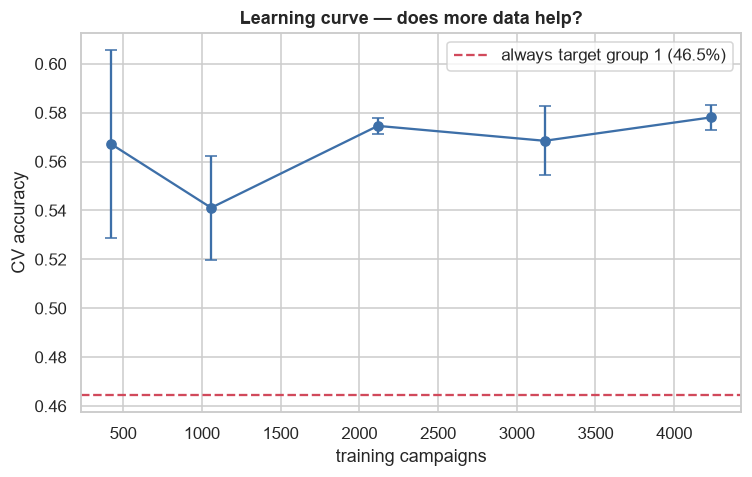

,n_train,cv_mean,cv_std,gain_vs_previous
fraction,,,,
0.100000,423,0.5672,0.0383,+nan
0.250000,1059,0.5411,0.0213,-0.0261
0.500000,2118,0.5746,0.0034,+0.0335
0.750000,3177,0.5685,0.0141,-0.0061
1.000000,4236,0.5781,0.0051,+0.0097


In [14]:
# Refit the Random Forest on increasing fractions of training data and evaluate each point with the same five-fold splitter. 
# The curve estimates sample-size sensitivity for this dataset; it cannot prove that additional data has no value.

learning_curve = learning_curve_report(build_pipeline(candidate_models(RANDOM_STATE)[CHAMPION]), X_fit, y_fit, cv, fractions=(0.1, 0.25, 0.5, 0.75, 1.0))

# Persist the numeric curve, export the figure, and show fold uncertainty.
ADVANCED_RESULTS["learning_curve"] = ( learning_curve.reset_index().to_dict(orient="records"))

fig = plot_learning_curve(learning_curve, NAIVE_BASELINE)
save_fig(fig, "05_learning_curve.png")
plt.show()

learning_curve.style.format({"cv_mean": "{:.4f}", "cv_std": "{:.4f}", "gain_vs_previous": "{:+.4f}"})


**Result.** The curve is non-monotonic. Moving from 75% to 100% of training data adds **0.0097 accuracy**, while smaller fractions fluctuate more strongly.

**Decision impact.** The evidence suggests modest marginal improvement and high sampling variability. It does **not** justify the statement that more data will not help. Time, campaign identifiers, and higher-quality business variables may be more valuable than simply adding similar rows.


---

## 7. Post-hoc minimal-model check

**Question.** Does the surprising `c_2`-only CV result also appear on the holdout?

This section deliberately reuses the holdout after the canonical model has been reported. It is a diagnostic, not a valid replacement-selection exercise. Promoting a one-feature model would require a fresh test set or nested evaluation designed for feature-count selection.


In [15]:
# Fit a one-feature version of the champion using the calibration-ranked leader, then compare it with the locked model on the already-used holdout. 
# This is an explicitly post-hoc check and cannot promote a replacement model.

minimal = minimal_model_comparison( top_feature=perm.index[0], champion_name=CHAMPION, x_fit=X_fit, y_fit=y_fit, x_test=X_test, 
                                   y_test=y_test, random_state=RANDOM_STATE, champion_test_accuracy=CHAMPION_TEST_ACCURACY)

# Store the comparison so the appendix clearly labels the result as post-hoc.
ADVANCED_RESULTS["post_hoc_minimal_model"] = (minimal.table.reset_index().to_dict(orient="records"))


In [16]:
# Extract the one-feature Random Forest and test whether its predictions transform consistently when Group 1 and Group 2 are mirrored using the inferred mapping.

minimal_model = minimal.single_models[CHAMPION]
minimal_invariance = measure_invariance(lambda frame: minimal_model.predict(frame[[minimal.top_feature]]), X_test, NEGATE_COLUMNS)

# Record and display violation and position-bias rates. Because the swap contract is inferred, this remains a warning diagnostic rather than an acceptance gate.

ADVANCED_RESULTS["post_hoc_minimal_model_symmetry"] = { "violation_rate": minimal_invariance.violation_rate, "position_bias": minimal_invariance.position_bias}
invariance_table(minimal_invariance)


,value
predictions that FAILED to transform correctly under a group swap,89.35%
"position bias, P(predict 1) − P(predict 2)",+29.38%
class-0 predictions that correctly stayed class 0,100.00%
failure rate per predicted class,"{'predicted_0': 0.0, 'predicted_1': 1.0, 'pred..."


**Result.** The post-hoc `c_2`-only Random Forest reaches **56.42% holdout accuracy**, compared with **54.83%** for the canonical 67-feature model. Its group-swap transformation failure rate is **89.35%** because the single unchanged input cannot reliably exchange class-1 and class-2 predictions.

**Correct interpretation.** This does not prove that `c_2` is direction-dependent. It shows that a one-feature model can exploit predictive structure and class/position priors while failing the expected action symmetry. Together with reuse of the holdout, that is sufficient reason **not to promote it**.


---

## 8. Assumption sensitivity and fitted-model invariance

### 8.1 Hypothetical cost scenarios

The dataset contains no campaign spend, margin, or customer-lifetime value. The following table uses stated relative units only to show whether decisions are sensitive to assumed economics.


In [17]:
# Evaluate how predicted actions change under three transparent, hypothetical cost/benefit ratios. 
# These are relative units—not observed spend, margin, profit, or ROI—so the output is sensitivity analysis only.

cost_sensitivity = cost_sensitivity_table( y_test.to_numpy(), champion.predict_proba(X_test),
    {
        "balanced — spend = profit": (1.0, 1.0, 0.5),
        "expensive campaigns — spend = 2× profit": (2.0, 1.0, 0.5),
        "high upside — profit = 3× spend": (1.0, 3.0, 0.5),
    },
)
cost_sensitivity


,cost/campaign — argmax,cost/campaign — decision rule,saving/campaign,decisions differing,flagged for review
scenario,,,,,
balanced — spend = profit,-0.1061,-0.1114,+0.0053,38,7.5%
expensive campaigns — spend = 2× profit,+0.2844,+0.1711,+0.1133,614,7.0%
high upside — profit = 3× spend,-1.0993,-1.2508,+0.1514,109,1.7%


**Result.** The number of actions differing from ordinary argmax ranges from 38 to 614 across the three assumed scenarios.

**Decision impact.** The action policy is economically sensitive, but the magnitudes are not business evidence. Real spend and margin values must be supplied before enabling a cost-sensitive decision layer or claiming ROI.


### 8.2 Fitted-model group-swap diagnostic

This diagnostic asks whether predictions transform as `0→0`, `1→2`, and `2→1` under the inferred swap operation. Because group positions were not exchangeable and some anonymised comparison transformations remain uncertain, the result is diagnostic rather than a production acceptance criterion.


In [18]:
# Apply the inferred group swap to holdout rows and test the expected prediction mapping 0->0, 1->2, and 2->1. 
# Since feature transformations are partially inferred and positions failed exchangeability checks, this is diagnostic only.

invariance = measure_invariance(champion.predict, X_test, NEGATE_COLUMNS)
ADVANCED_RESULTS["canonical_model_symmetry"] = { "violation_rate": invariance.violation_rate, "position_bias": invariance.position_bias, 
                                                "class_0_stay_rate": invariance.class_0_stay_rate,}
invariance_table(invariance)


,value
predictions that FAILED to transform correctly under a group swap,53.78%
"position bias, P(predict 1) − P(predict 2)",+28.63%
class-0 predictions that correctly stayed class 0,24.77%
failure rate per predicted class,"{'predicted_0': 0.7523, 'predicted_1': 0.5044,..."


**Result.** The canonical model fails to transform as expected on **53.78%** of swapped rows, and only **24.77%** of its class-0 predictions remain class 0 after the inferred swap.

**Decision impact.** Do not interpret this as a definitive model defect: the swap itself is only partially identified and the two positions are not exchangeable. It is a warning that upstream ordering conventions must remain stable and that a reliable data dictionary is required before enforcing symmetry.


---

## 9. Diagnostic decisions

| Experiment | Evidence | Production decision |
|---|---|---|
| Comparison redundancy | 15 of 27 `c_` variables reconstructible | Keep contract; investigate lineage |
| Swap augmentation | Distribution and exchangeability checks fail | Do not augment |
| SHAP cross-check | Confirms `c_2` dominance | Explain predictive influence only |
| Stacking | Small gain under reduced protocol | Do not deploy |
| Decline threshold | Predefined rule rejects all thresholds | Keep argmax |
| Feature reduction | `c_2` result is strong but exploratory | Do not replace canonical model |
| Learning curve | Small, noisy marginal gain | Do not claim data cannot help |
| Cost sensitivity | Decisions vary with assumed economics | Obtain real business values |
| Swap invariance | High diagnostic failure rate | Stabilise input ordering; obtain semantics |

None of these experiments changes the deployed Random Forest or its canonical **54.83% accuracy / +8.38 pp offline lift**.


In [19]:
# Export only appendix diagnostics. This cell deliberately cannot overwrite the canonical findings.json, model artifact, leaderboard, or campaign-outcome files.
(REPORTS / "advanced_diagnostics.json").write_text( json.dumps(ADVANCED_RESULTS, indent=2, default=str), encoding="utf-8")
print("Exported reports/advanced_diagnostics.json")


Exported reports/advanced_diagnostics.json
